# 📊 Análise de Risco de Crédito com Machine Learning

## 🎯 Objetivo

Desenvolver um modelo preditivo para estimar a probabilidade de inadimplência e transformar essas previsões em um sistema de decisão aplicado ao negócio.

O foco do projeto não é apenas a modelagem, mas a construção de regras de decisão que equilibrem risco, aprovação de clientes e impacto financeiro, simulando um cenário real de concessão de crédito.

---

## 🧠 Problema de Negócio

Instituições financeiras precisam tomar decisões críticas como:

- Quem deve receber crédito?
- Quais clientes apresentam alto risco?
- Quando é necessário revisar uma decisão manualmente?

Erros nesse processo geram impactos diretos:

- **Falsos negativos** → inadimplentes aprovados (prejuízo financeiro)
- **Falsos positivos** → bons clientes negados (perda de receita)

---

## 🚀 Abordagem

O projeto foi estruturado para conectar modelagem preditiva à tomada de decisão:

1. Construção de modelo para estimar risco de inadimplência  
2. Avaliação com métricas adequadas para dados desbalanceados (foco em recall)  
3. Ajuste de threshold para controle de risco  
4. Criação de regras de decisão (aprovar, revisar, negar)  
5. Simulação de impacto financeiro das decisões  

---

## Fazendo a importação das bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn import metrics
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix

from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split

# 1. Conhecendo a Base de Dados

In [ ]:
dados = pd.read_csv('/content/payflow_credit_risk.csv')
dados.head()

,id_cliente,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,...,dias_atraso_max_12m,reclamacoes_6m,possui_avalista,canal_aquisicao,regiao,tipo_produto,parcelas_pagas_ate_3m,atraso_primeira_parcela_dias,status_apos_90d,default_90d
0,1,22,2639.75,2.718888,0,617.0,2619.14,12,3.96,3,...,0,0,0,site,Sul,emprestimo_pessoal,0,29,default,1
1,2,59,2482.34,10.785992,0,619.0,9101.21,36,3.37,2,...,0,0,0,app,Sudeste,cartao,2,10,em_dia,0
2,3,52,6230.69,9.547608,0,665.0,13258.67,48,3.12,0,...,0,0,0,loja,Sudeste,cartao,2,0,em_dia,0
3,4,41,6469.45,4.287084,0,676.0,1407.28,12,1.52,2,...,90,1,0,parceiro,Sudeste,emprestimo_pessoal,3,0,em_dia,0
4,5,40,2343.04,0.000000,0,671.0,2647.92,48,3.07,1,...,15,0,0,app,Nordeste,bnpl,2,10,em_atraso_leve,0


##  Análises Preliminares

###  Estrutura dos Dados (`dados.info()`)
- Exibe o tamanho do dataset (5.000 linhas, 23 colunas)  
- Mostra os tipos de dados (numéricos e categóricos)  
- Identifica colunas com valores nulos  


In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_cliente                    5000 non-null   int64  
 1   idade                         5000 non-null   int64  
 2   renda_mensal                  4808 non-null   float64
 3   tempo_emprego_anos            4474 non-null   float64
 4   autonomo                      5000 non-null   int64  
 5   score_credito                 5000 non-null   float64
 6   valor_solicitado              5000 non-null   float64
 7   prazo_meses                   5000 non-null   int64  
 8   juros_mensal_pct              5000 non-null   float64
 9   qtde_cartoes                  5000 non-null   int64  
 10  qtde_contratos_abertos        5000 non-null   int64  
 11  utilizacao_credito            5000 non-null   float64
 12  inadimplencias_anteriores     5000 non-null   int64  
 13  dia

###  Variáveis Categóricas
- Verifica os valores únicos das colunas categóricas:
  - `canal_aquisicao`
  - `regiao`
  - `tipo_produto`  
- Objetivo: entender as categorias presentes na base  


In [ ]:
print(f'Dados canal_aquisicao: {dados.canal_aquisicao.unique()}')
print(f'Dados regiao: {dados.regiao.unique()}')
print(f'Dados tipo_produto: {dados.tipo_produto.unique()}')

Dados canal_aquisicao: ['site' 'app' 'loja' 'parceiro']
Dados regiao: ['Sul' 'Sudeste' 'Nordeste' 'Centro-Oeste' 'Norte']
Dados tipo_produto: ['emprestimo_pessoal' 'cartao' 'bnpl']


###  Distribuição da Variável Alvo
- Analisa a quantidade de clientes inadimplentes vs não inadimplentes  
- Objetivo: verificar se a base é balanceada  


In [ ]:
dados['default_90d'].value_counts()

,count
default_90d,
0,4391
1,609


###  Valores Nulos
- Identifica a quantidade de valores ausentes por coluna  
- Objetivo: definir estratégias de tratamento (ex: imputação)  


In [ ]:
print(dados.isnull().sum())

id_cliente                        0
idade                             0
renda_mensal                    192
tempo_emprego_anos              526
autonomo                          0
score_credito                     0
valor_solicitado                  0
prazo_meses                       0
juros_mensal_pct                  0
qtde_cartoes                      0
qtde_contratos_abertos            0
utilizacao_credito                0
inadimplencias_anteriores         0
dias_atraso_max_12m               0
reclamacoes_6m                    0
possui_avalista                   0
canal_aquisicao                   0
regiao                            0
tipo_produto                      0
parcelas_pagas_ate_3m             0
atraso_primeira_parcela_dias      0
status_apos_90d                   0
default_90d                       0
dtype: int64


###  Valores Duplicados
- Verifica registros duplicados na base  
- Objetivo: garantir qualidade e consistência dos dados  


In [ ]:
print(f'Dados duplicados: {dados.duplicated().sum()}')

Dados duplicados: 0


###  Estatísticas Descritivas (`describe()`)
- Resume métricas das variáveis numéricas:
  - média, mediana, desvio padrão, mínimo e máximo  
- Objetivo: entender distribuição, dispersão e possíveis outliers

In [ ]:
dados.describe().round(2)

,id_cliente,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,qtde_contratos_abertos,utilizacao_credito,inadimplencias_anteriores,dias_atraso_max_12m,reclamacoes_6m,possui_avalista,parcelas_pagas_ate_3m,atraso_primeira_parcela_dias,default_90d
count,5000.00,5000.00,4808.00,4474.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,2500.50,43.93,4692.97,4.77,0.16,653.59,11277.88,25.44,2.82,1.18,1.01,0.33,0.29,12.08,0.42,0.19,2.26,12.72,0.12
std,1443.52,15.34,4005.36,3.52,0.37,85.27,10542.62,15.37,0.93,1.10,1.01,0.18,0.60,24.01,0.66,0.39,0.82,23.67,0.33
min,1.00,18.00,800.00,0.00,0.00,350.00,500.00,6.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1250.75,31.00,2136.48,1.84,0.00,596.00,4466.43,12.00,2.20,0.00,0.00,0.19,0.00,0.00,0.00,0.00,2.00,0.00,0.00
50%,2500.50,44.00,3496.40,4.64,0.00,655.00,7981.62,24.00,2.83,1.00,1.00,0.31,0.00,0.00,0.00,0.00,2.00,5.00,0.00
75%,3750.25,57.00,5863.25,7.12,0.00,711.00,14095.93,36.00,3.45,2.00,2.00,0.45,0.00,15.00,1.00,0.00,3.00,15.00,0.00
max,5000.00,70.00,35000.00,18.79,1.00,900.00,60000.00,60.00,6.30,6.00,7.00,1.00,3.00,120.00,4.00,1.00,3.00,119.00,1.00


# 2. Tratamento e Pré-Processamento dos Dados

###  Remoção de Variáveis (Leakage)
- Remoção de colunas que representam informações futuras ou irrelevantes:
  - `id_cliente`
  - `parcelas_pagas_ate_3m`
  - `atraso_primeira_parcela_dias`
  - `status_apos_90d`  
- Objetivo: evitar vazamento de informação e garantir um modelo realista  


In [ ]:
dados = dados.drop(['id_cliente', 'parcelas_pagas_ate_3m', 'atraso_primeira_parcela_dias', 'status_apos_90d'], axis=1)

###  Tratamento de Valores Nulos

####  `tempo_emprego_anos`
- Valores nulos preenchidos com **0**  
- Interpretação: cliente sem vínculo formal ou desempregado  


In [ ]:
dados['tempo_emprego_anos'] = dados['tempo_emprego_anos'].fillna(0)

In [ ]:
dados['tempo_emprego_anos'].isnull().sum()

np.int64(0)


####  `renda_mensal`
- Valores nulos substituídos pela **mediana**  
- Objetivo: reduzir impacto de outliers e manter consistência dos dados  


In [ ]:
median = dados['renda_mensal'].median()
dados['renda_mensal'] = dados['renda_mensal'].fillna(median)

##  Feature Engineering

###  Criação de Variáveis

Com base nos insights do EDA, foram criadas variáveis para representar melhor o risco financeiro:

- `comprometimento_renda` = valor_solicitado / renda_mensal  
- `parcela_estimada` = valor_solicitado / prazo_meses  
- `parcela_renda` = parcela_estimada / renda_mensal  

---

###  Objetivo

Capturar a **capacidade de pagamento** e o nível de **comprometimento da renda**.

---

###  Insight (EDA)

Clientes inadimplentes tendem a apresentar maior pressão financeira, o que justifica a criação dessas variáveis.


In [ ]:
dados['comprometimento_renda'] = dados['valor_solicitado'] / dados['renda_mensal']
dados['parcela_estimada'] = dados['valor_solicitado'] / dados['prazo_meses']
dados['parcela_renda'] = dados['parcela_estimada'] / dados['renda_mensal']

In [ ]:
dados[['renda_mensal', 'comprometimento_renda', 'parcela_estimada', 'parcela_renda', 'default_90d']].head()

,renda_mensal,comprometimento_renda,parcela_estimada,parcela_renda,default_90d
0,2639.75,0.992192,218.261667,0.082683,1
1,2482.34,3.666383,252.811389,0.101844,0
2,6230.69,2.127962,276.222292,0.044333,0
3,6469.45,0.217527,117.273333,0.018127,0
4,2343.04,1.130122,55.165000,0.023544,0


##  Separação de Variáveis (X e y)

- `X`: variáveis explicativas (features)  
- `y`: variável alvo (`default_90d`)  

Objetivo: separar os dados entre **entrada (X)** e **resposta (y)** para modelagem  

In [ ]:
X = dados.drop('default_90d', axis=1)

y = dados['default_90d']

## Divisão em Treino e Teste

- Divisão dos dados em:
  - **Treino (80%)**
  - **Teste (20%)**  

- Utilizada **estratificação (`stratify=y`)** para manter a proporção de inadimplentes  


In [ ]:
x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, stratify=y, test_size=0.2, random_state=123)

##  Pré-processamento dos Dados

###  Variáveis Numéricas
- Aplicado **StandardScaler** para padronização  
- Objetivo: colocar todas as variáveis na mesma escala  


In [ ]:
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

In [ ]:
dados_num = ['idade', 'renda_mensal', 'tempo_emprego_anos', 'autonomo',
       'score_credito', 'valor_solicitado', 'prazo_meses', 'juros_mensal_pct',
       'qtde_cartoes', 'qtde_contratos_abertos', 'utilizacao_credito',
       'inadimplencias_anteriores', 'dias_atraso_max_12m', 'reclamacoes_6m',
       'possui_avalista', 'comprometimento_renda', 'parcela_estimada',
       'parcela_renda']
dados_categoricos = ['canal_aquisicao', 'regiao', 'tipo_produto']


###  Variáveis Categóricas
- Aplicado **One-Hot Encoding**  
- Objetivo: transformar categorias em formato numérico  


###  Pipeline de Transformação
- Utilizado `ColumnTransformer` para aplicar:
  - Escalonamento nas variáveis numéricas  
  - Encoding nas variáveis categóricas  


In [ ]:
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, dados_num),
    ('cat', OneHotEncoder(), dados_categoricos)
])

x_treino_tratado = full_pipeline.fit_transform(x_treino)
x_teste_tratado = full_pipeline.transform(x_teste)

In [ ]:
num_cols = dados_num
cat_cols = full_pipeline.named_transformers_['cat'].get_feature_names_out(dados_categoricos)

In [ ]:
X_treino = pd.DataFrame(x_treino_tratado, columns= list(num_cols) + list(cat_cols))
X_teste = pd.DataFrame(x_teste_tratado, columns= list(num_cols) + list(cat_cols))

In [ ]:
X_treino.head()

,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,qtde_contratos_abertos,...,canal_aquisicao_parceiro,canal_aquisicao_site,regiao_Centro-Oeste,regiao_Nordeste,regiao_Norte,regiao_Sudeste,regiao_Sul,tipo_produto_bnpl,tipo_produto_cartao,tipo_produto_emprestimo_pessoal
0,-1.635694,-0.022898,0.804773,-0.430331,0.870363,0.304668,0.679944,-0.741228,-1.089820,-0.989673,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-1.570553,0.949641,-1.188106,2.323790,-0.147623,0.692594,-0.096192,0.403559,-1.089820,-0.989673,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,-0.528306,-0.623964,0.537879,-0.430331,0.402324,-0.632166,-0.096192,-0.730428,-0.169558,-0.989673,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.049429,0.864492,-0.519448,-0.430331,0.601241,-0.692888,-0.872329,0.155162,-0.169558,-0.000495,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-1.179710,1.420081,-1.188106,-0.430331,1.946854,-0.484982,2.232216,-1.756416,-0.169558,-0.000495,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


# 3. Modelos de Machine Learning

##  Objetivo
Comparar diferentes modelos para identificar inadimplentes (classe 1), priorizando métricas adequadas para dados desbalanceados.

---

##  Estratégia
- Modelos testados: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, KNN, XGBoost e LightGBM  



In [ ]:
# Colocando o dicionário com os modeloes que serão utilizados
modelos_classificacao = {
    'Logistic Regression': LogisticRegression(class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=5),
    'Random Forest': RandomForestClassifier(n_estimators=42, random_state=42, class_weight='balanced', max_depth=5),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, max_depth=5),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(random_state=42, max_depth=5),
    'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
}

In [ ]:
resultados = []

for nome, modelo in modelos_classificacao.items():
  modelo.fit(X_treino, y_treino)
  pred = modelo.predict(X_teste)

  resultados.append({
      'Modelo': nome,
      'Acurácia': metrics.accuracy_score(y_teste, pred),
      'Recall_0': metrics.recall_score(y_teste, pred, pos_label=0),
      'Recall_1': metrics.recall_score(y_teste, pred, pos_label=1),
      'Precision_0': metrics.precision_score(y_teste, pred, pos_label=0),
      'Precision_1': metrics.precision_score(y_teste, pred, pos_label=1),
      'F1-Score': metrics.f1_score(y_teste, pred)
  })

resultado_df = pd.DataFrame(resultados).sort_values('Recall_1', ascending=False)
resultado_df

,Modelo,Acurácia,Recall_0,Recall_1,Precision_0,Precision_1,F1-Score
0,Logistic Regression,0.755,0.763098,0.696721,0.947666,0.290102,0.409639
1,Decision Tree,0.750,0.766515,0.631148,0.937326,0.273050,0.381188
2,Random Forest,0.821,0.862187,0.524590,0.928834,0.345946,0.416938
3,Gradient Boosting,0.885,0.973804,0.245902,0.902851,0.566038,0.342857
5,XGBoost,0.879,0.974943,0.188525,0.896335,0.511111,0.275449
6,LightGBM,0.875,0.978360,0.131148,0.890155,0.457143,0.203822
4,K-Nearest Neighbors,0.877,0.984055,0.106557,0.887975,0.481481,0.174497


#### Análise Final

Os modelos foram ordenados com base no Recall_1, priorizando a capacidade de identificar clientes inadimplentes.

Observa-se que a Regressão Logística, Decision Tree e Random Forest apresentam os melhores resultados nesse critério, com destaque para maior sensibilidade na detecção de risco.

Apesar de alguns modelos apresentarem maior acurácia, eles demonstram menor capacidade de identificar inadimplentes, o que os torna menos adequados para o contexto do problema.

Dessa forma, os três primeiros modelos serão avaliados em maior profundidade nas próximas etapas, considerando o trade-off entre recall, precisão e impacto de negócio.

##  Análise dos Modelos Selecionados

Nesta etapa, é realizada uma análise mais detalhada dos três modelos com melhor desempenho em Recall_1: Regressão Logística, Decision Tree e Random Forest.

A avaliação é feita com base no `classification_report`, permitindo observar o comportamento de cada modelo para ambas as classes, com foco especial na capacidade de identificar inadimplentes (classe 1).

In [ ]:
for nome in ['Logistic Regression', 'Decision Tree', 'Random Forest']:
  modelo = modelos_classificacao[nome]
  modelo.fit(X_treino, y_treino)
  pred = modelo.predict(X_teste)

  print(f'Modelo: {nome}')
  print(classification_report(y_teste, pred))

Modelo: Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.76      0.85       878
           1       0.29      0.70      0.41       122

    accuracy                           0.76      1000
   macro avg       0.62      0.73      0.63      1000
weighted avg       0.87      0.76      0.79      1000

Modelo: Decision Tree
              precision    recall  f1-score   support

           0       0.94      0.77      0.84       878
           1       0.27      0.63      0.38       122

    accuracy                           0.75      1000
   macro avg       0.61      0.70      0.61      1000
weighted avg       0.86      0.75      0.79      1000

Modelo: Random Forest
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       878
           1       0.35      0.52      0.42       122

    accuracy                           0.82      1000
   macro avg       0.64      0.69      0.66      1000
we

#### Análise Final

A Regressão Logística apresentou o melhor recall para a classe inadimplente, indicando maior capacidade de identificar clientes de risco. No entanto, sua precisão é mais baixa, refletindo maior quantidade de falsos positivos.

A Decision Tree apresentou desempenho intermediário, com recall menor que a Regressão Logística e sem ganhos relevantes em precisão.

Já o Random Forest apresentou maior precisão para a classe inadimplente, porém com recall significativamente menor, indicando que deixa passar mais clientes de risco.

Esses resultados evidenciam o trade-off entre recall e precisão, sendo necessário ajustar o ponto de decisão do modelo para equilibrar risco e oportunidade.

Dessa forma, a próxima etapa será a análise por diferentes thresholds, utilizando as probabilidades previstas para definir regras de decisão mais alinhadas ao contexto de negócio.

# 4. Ajustando o Limiar de Decisão

##  Análise de Threshold

Nesta etapa, analisamos o impacto de diferentes thresholds na performance dos modelos selecionados.

Ao invés de utilizar o valor padrão de 0.5, avaliamos como a variação do threshold influencia o equilíbrio entre recall e precisão, com foco na identificação de inadimplentes (classe 1).

Essa abordagem permite entender como ajustar o modelo para diferentes estratégias de negócio, controlando o nível de risco e a taxa de falsos positivos.

### Regressão Logística

In [ ]:
modelo_lr = LogisticRegression(class_weight='balanced')
modelo_lr.fit(X_treino, y_treino)
y_prob = modelo_lr.predict_proba(X_teste)[:,1]

for t in [0.3, 0.4, 0.5]:
  y_pred_t = (y_prob >= t).astype(int)
  print(f'\nThreshold: {t}')
  print(classification_report(y_teste, y_pred_t))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.96      0.44      0.61       878
           1       0.18      0.87      0.30       122

    accuracy                           0.49      1000
   macro avg       0.57      0.66      0.45      1000
weighted avg       0.87      0.49      0.57      1000


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.95      0.63      0.76       878
           1       0.22      0.74      0.34       122

    accuracy                           0.65      1000
   macro avg       0.58      0.69      0.55      1000
weighted avg       0.86      0.65      0.71      1000


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.95      0.76      0.85       878
           1       0.29      0.70      0.41       122

    accuracy                           0.76      1000
   macro avg       0.62      0.73      0.63      1000
weighted avg       0.87   

### Decision Tree

In [ ]:
modelo_dt = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=5)
modelo_dt.fit(X_treino, y_treino)
y_pred_dt = modelo_dt.predict_proba(X_teste)[:,1]

for t in [0.3, 0.4, 0.5]:
  y_pred_t = (y_pred_dt >= t).astype(int)
  print(f'\nThreshold: {t}')
  print(classification_report(y_teste, y_pred_t))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.93      0.53      0.67       878
           1       0.17      0.70      0.27       122

    accuracy                           0.55      1000
   macro avg       0.55      0.61      0.47      1000
weighted avg       0.83      0.55      0.62      1000


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.53      0.67       878
           1       0.17      0.70      0.27       122

    accuracy                           0.55      1000
   macro avg       0.55      0.61      0.47      1000
weighted avg       0.83      0.55      0.62      1000


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.94      0.77      0.84       878
           1       0.27      0.63      0.38       122

    accuracy                           0.75      1000
   macro avg       0.61      0.70      0.61      1000
weighted avg       0.86   

### Random Forest

In [ ]:
modelo_rf = RandomForestClassifier(n_estimators=42, random_state=42, class_weight='balanced', max_depth=5)
modelo_rf.fit(X_treino, y_treino)
y_pred_rf = modelo_rf.predict_proba(X_teste)[:,1]

for t in [0.3, 0.4, 0.5]:
  y_pred_t = (y_pred_rf >= t).astype(int)
  print(f'\nThreshold: {t}')
  print(classification_report(y_teste, y_pred_t))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.97      0.22      0.35       878
           1       0.15      0.96      0.25       122

    accuracy                           0.31      1000
   macro avg       0.56      0.59      0.30      1000
weighted avg       0.87      0.31      0.34      1000


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.95      0.65      0.77       878
           1       0.22      0.74      0.34       122

    accuracy                           0.66      1000
   macro avg       0.59      0.69      0.56      1000
weighted avg       0.86      0.66      0.72      1000


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       878
           1       0.35      0.52      0.42       122

    accuracy                           0.82      1000
   macro avg       0.64      0.69      0.66      1000
weighted avg       0.86   

### Análise Final dos Thresholds


A Regressão Logística apresentou o melhor equilíbrio entre recall e precisão ao variar o threshold, mantendo boa capacidade de identificar inadimplentes sem gerar excesso de falsos positivos.

A Decision Tree não apresentou ganhos relevantes com o ajuste de threshold.

O Random Forest mostrou comportamento mais instável, com alto recall em thresholds baixos, porém com precisão muito baixa.

Dessa forma, a Regressão Logística com threshold intermediário (≈ 0.4) foi escolhida como base para a definição das regras de decisão.


# 5. Analisando Regressão Logística - Treshold 0.4


Nesta etapa, avaliamos o desempenho da Regressão Logística utilizando threshold de 0.4, definido anteriormente como ponto de equilíbrio entre recall e precisão.

A análise considera a matriz de confusão e a curva ROC, permitindo entender tanto a capacidade de classificação quanto o poder de separação do modelo.

In [ ]:
y_prob = modelo_lr.predict_proba(X_teste)[:, 1]

threshold = 0.4
y_pred_lr_prob = (y_prob >= threshold).astype(int)

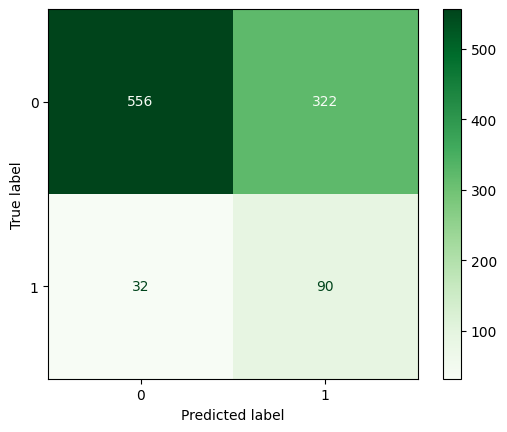

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_teste, y_pred_lr_prob, cmap='Greens');

### Análise – Matriz de Confusão

O modelo apresenta bom desempenho na identificação de inadimplentes, com alto recall para a classe de interesse.

Observa-se, porém, uma quantidade relevante de falsos positivos, indicando que parte dos clientes bons está sendo classificada como risco.

Esse comportamento mostra que o modelo está mais orientado à redução de risco, aceitando um aumento na rejeição de clientes bons como trade-off.

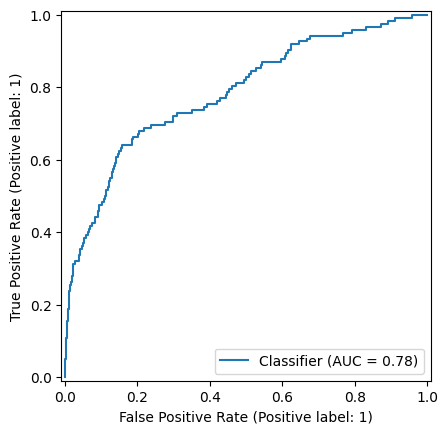

In [ ]:
RocCurveDisplay.from_predictions(y_teste, y_prob);

### Análise – Curva ROC

A curva ROC apresenta AUC ≈ 0.78, indicando boa capacidade de separação entre clientes adimplentes e inadimplentes.

Isso significa que o modelo consegue distinguir razoavelmente bem os dois grupos, sendo adequado como base para definição de regras de decisão.

Apesar de não ser um modelo altamente preciso, seu desempenho é suficiente para aplicações práticas quando combinado com thresholds ajustados ao contexto de negócio.

#  6. Validação Cruzada — Regressão Logística (Threshold = 0.4)

### Objetivo

Avaliar a consistência e a capacidade de generalização da Regressão Logística utilizando validação cruzada estratificada com threshold de 0.4.

Essa etapa permite verificar se o desempenho observado anteriormente se mantém de forma estável em diferentes divisões dos dados, reduzindo o risco de conclusões baseadas em um único split de treino e teste.


In [ ]:
modelo_lr = LogisticRegression(class_weight='balanced', random_state=42)
validacao = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

In [ ]:
threshold = 0.4

def recall_threshold(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return metrics.recall_score(y, y_pred)

def precision_threshold(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return metrics.precision_score(y, y_pred, zero_division=0)

def f1_threshold(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return metrics.f1_score(y, y_pred, zero_division=0)

resultado_validacao = cross_validate(
    modelo_lr,
    X_treino,
    y_treino,
    cv=validacao,
    scoring={
        'recall_t04': recall_threshold,
        'precision_t04': precision_threshold,
        'f1_t04': f1_threshold
    },
    return_train_score=False
)

In [ ]:
print('Resultado Validação - Regressão Logística (threshold=0.4)')
print('Recall médio:', np.mean(resultado_validacao['test_recall_t04']).round(3))
print('Precisão média:', np.mean(resultado_validacao['test_precision_t04']).round(3))
print('F1 médio:', np.mean(resultado_validacao['test_f1_t04']).round(3))

Resultado Validação - Regressão Logística (threshold=0.4)
Recall médio: 0.735
Precisão média: 0.217
F1 médio: 0.335


### Análise Final Validação Cruzada

Os resultados da validação cruzada mostram que a Regressão Logística mantém desempenho consistente na identificação de inadimplentes, com recall médio de 0.735.

A precisão média de 0.217 indica que o modelo continua priorizando sensibilidade à classe inadimplente, mesmo com presença relevante de falsos positivos.

O F1 médio de 0.335 reforça esse comportamento, mostrando um modelo mais orientado à redução de risco do que ao equilíbrio entre as métricas.

De forma geral, a validação cruzada confirma que a Regressão Logística com threshold de 0.4 apresenta comportamento estável e adequado como base para a definição das regras de decisão do negócio.

# 7. Importância das Variáveis

### Objetivo

Identificar quais variáveis mais influenciam a probabilidade de inadimplência com base nos coeficientes da Regressão Logística.

Essa análise permite entender como cada variável impacta o risco, trazendo maior interpretabilidade ao modelo e apoiando decisões de negócio.

In [ ]:
modelo_lr = LogisticRegression(class_weight='balanced')
modelo_lr.fit(X_treino, y_treino)

coef = modelo_lr.coef_[0]

importancia = pd.DataFrame({
    'feature': X_treino.columns,
    'coeficiente': coef
})

importancia['abs_coef'] = importancia['coeficiente'].abs()

importancia = importancia.sort_values(by='abs_coef', ascending=False)

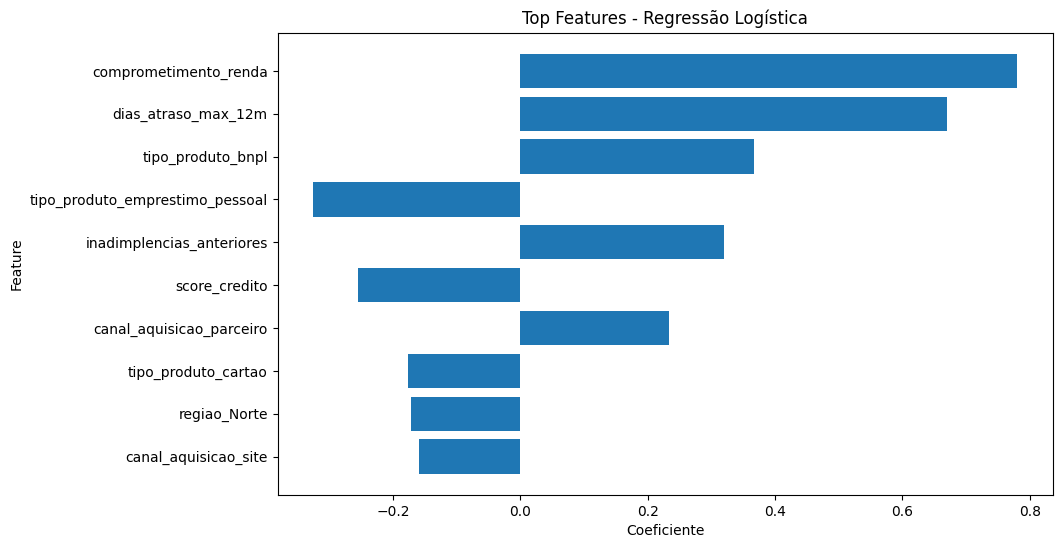

In [ ]:
import matplotlib.pyplot as plt

top_n = 10

top_features = importancia.head(top_n)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['feature'],
    top_features['coeficiente']
)

plt.gca().invert_yaxis()

plt.title('Top Features - Regressão Logística')
plt.xlabel('Coeficiente')
plt.ylabel('Feature')

plt.show()

### Análise Final

As variáveis relacionadas ao comportamento financeiro do cliente, como comprometimento de renda e histórico de atraso, apresentam maior influência na previsão de inadimplência.

Fatores como inadimplências anteriores e score de crédito também se destacam, reforçando a importância do histórico financeiro na avaliação de risco.

Além disso, características do produto e canal de aquisição mostram impacto relevante, indicando que o tipo de crédito e a origem do cliente podem influenciar o nível de risco.

De forma geral, o modelo está alinhado com a lógica de negócio, priorizando variáveis que refletem capacidade de pagamento e comportamento passado do cliente.

# 8.  Probabilidades e Regras de Decisão

Nesta etapa, utilizamos as probabilidades previstas pelo modelo para construir regras de decisão mais alinhadas ao contexto de negócio.

Ao invés de uma classificação binária, definimos três níveis de decisão:

- Aprovar → baixo risco  
- Revisar → risco intermediário  
- Negar → alto risco  

Essa abordagem permite maior controle sobre o risco da carteira, equilibrando aprovação de clientes e prevenção de inadimplência.


In [ ]:
modelo_lr = LogisticRegression(class_weight='balanced')
modelo_lr.fit(X_treino, y_treino)

LogisticRegression(class_weight='balanced')

In [ ]:
probabilidades = modelo_lr.predict_proba(X_teste)[:, 1]

In [ ]:
df_decisao = pd.DataFrame({
    'Probabilidade': probabilidades,
    'Realidade': y_teste
})

##  Estratégia

Com base na probabilidade de inadimplência:

- **≥ 0.70 → Negar crédito**  
- **≥ 0.40 → Revisar manualmente**  
- **< 0.40 → Aprovar**  


In [ ]:
condicoes = [
    df_decisao['Probabilidade'] >= 0.7,
    df_decisao['Probabilidade'] >= 0.4
]

decisoes = ['Negar', 'Revisar']

df_decisao['Decisao_prob'] = np.select(condicoes, decisoes, default='Aprovar')

In [ ]:
df_decisao[['Probabilidade', 'Decisao_prob', 'Realidade']].head()

,Probabilidade,Decisao_prob,Realidade
3744,0.336779,Aprovar,0
1533,0.176650,Aprovar,0
3499,0.420530,Revisar,0
4560,0.309191,Aprovar,0
4356,0.545940,Revisar,0



## Distribuição das Decisões

- **Aprovar:** 588  
- **Revisar:** 293  
- **Negar:** 119  


In [ ]:
print('Visualizando o impacto das regras de negócios')
print(df_decisao['Decisao_prob'].value_counts())

Visualizando o impacto das regras de negócios
Decisao_prob
Aprovar    588
Revisar    293
Negar      119
Name: count, dtype: int64


In [ ]:
pd.crosstab(df_decisao['Decisao_prob'], df_decisao['Realidade'], margins=True)

Realidade,0,1,All
Decisao_prob,,,
Aprovar,556,32,588
Negar,67,52,119
Revisar,255,38,293
All,878,122,1000


### Análise Final

As regras de decisão mostram uma separação clara entre os níveis de risco.

- A categoria **Aprovar** apresenta baixa taxa de inadimplência, indicando boa seleção de clientes de baixo risco  
- A categoria **Revisar** concentra casos intermediários, sendo adequada para análise manual  
- A categoria **Negar** reúne maior proporção de inadimplentes, validando a estratégia de bloqueio de clientes de alto risco  

Observa-se, porém, que ainda há uma quantidade relevante de clientes bons sendo negados, evidenciando o trade-off entre redução de risco e perda de oportunidade.

No geral, o modelo se mostra adequado para aplicação prática, permitindo transformar previsões em decisões mais estruturadas e alinhadas ao negócio.

# 8. Resultado Financeiro do Modelo

Nesta etapa, traduzimos o desempenho do modelo em impacto financeiro estimado.

A análise considera o custo de inadimplência (falsos negativos) e o custo de oportunidade de rejeitar bons clientes (falsos positivos), permitindo avaliar o valor prático das decisões geradas pelo modelo.

Essa abordagem conecta as métricas do modelo diretamente ao resultado de negócio.


In [ ]:
tn, fp, fn, tp = confusion_matrix(y_teste, y_pred_lr_prob).ravel()

prejuizo_por_calote = x_teste["valor_solicitado"].mean()
lucro_por_bom_cliente = x_teste["valor_solicitado"].mean() * 0.08

perda_evitada = tp * prejuizo_por_calote
prejuizo_falsos_negativos = fn * prejuizo_por_calote
lucro_perdido_falsos_positivos = fp * lucro_por_bom_cliente

impacto_liquido = (
    perda_evitada - prejuizo_falsos_negativos - lucro_perdido_falsos_positivos
)

print("--- RELATÓRIO DE IMPACTO FINANCEIRO (BASE DE TESTE) ---")
print(f"Total de calotes evitados: {tp}")
print(f"Perda evitada: R$ {perda_evitada:,.2f}")
print(f"Prejuízo com falsos negativos: R$ {prejuizo_falsos_negativos:,.2f}")
print(f"Custo de oportunidade (bons clientes negados): R$ {lucro_perdido_falsos_positivos:,.2f}")
print(f"Impacto líquido estimado: R$ {impacto_liquido:,.2f}")

--- RELATÓRIO DE IMPACTO FINANCEIRO (BASE DE TESTE) ---
Total de calotes evitados: 90
Perda evitada: R$ 1,006,969.18
Prejuízo com falsos negativos: R$ 358,033.49
Custo de oportunidade (bons clientes negados): R$ 288,216.96
Impacto líquido estimado: R$ 360,718.74


### Análise Final

O modelo demonstra impacto financeiro positivo, com valor líquido estimado de aproximadamente R$ 360 mil.

A principal contribuição vem da redução de perdas com inadimplência, representada pelos clientes de risco corretamente identificados.

Por outro lado, observa-se um custo relevante associado à rejeição de bons clientes, refletindo o trade-off entre redução de risco e perda de oportunidade.

No geral, o modelo se mostra eficaz em gerar valor para o negócio, priorizando a mitigação de perdas e mantendo um impacto financeiro líquido positivo.

# 💾 Salvando o Modelo

### 🔎 Objetivo

Persistir o modelo treinado e o pipeline de pré-processamento para uso em produção ou futuras previsões.


In [ ]:
joblib.dump(full_pipeline, 'pre-processamento.pkl')

joblib.dump(modelo_lr, 'modelo.pkl')

joblib.dump(X_treino.columns.tolist(), 'colunas_modelo.pkl')

['colunas_modelo.pkl']

## 🏁 Conclusão da Modelagem de Machine Learning

A etapa de modelagem permitiu transformar os insights obtidos no EDA em uma solução preditiva aplicada ao contexto de risco de crédito, conectando análise técnica à tomada de decisão de negócio.

---

## 🔍 Principais Resultados

- A **Regressão Logística** se destacou como modelo mais adequado para o problema, apresentando melhor capacidade de identificar inadimplentes  
- O ajuste de limiar evidenciou o trade-off entre recall e precisão, sendo definido o threshold **0.4** como ponto de equilíbrio mais alinhado ao contexto de risco  
- A validação cruzada confirmou a **consistência e estabilidade** do modelo  

Além disso:

- As variáveis mais relevantes estão alinhadas com o comportamento esperado de inadimplência  
- O uso de probabilidades permitiu evoluir de um modelo preditivo para um **sistema de decisão estruturado**  

---

## 💡 Valor Gerado

- O modelo foi capaz de **identificar clientes de risco e reduzir perdas com inadimplência**  
- A estratégia baseada em probabilidades permitiu:
  - Definir regras de decisão (aprovar, revisar, negar)  
  - Criar uma camada de controle de risco mais granular  
  - Apoiar decisões mais alinhadas ao negócio  

- A simulação financeira indicou um **impacto líquido positivo (~R$ 360 mil)**, reforçando a viabilidade da solução  

---

## 🧠 Insight Final

O projeto demonstrou que o valor do Machine Learning não está apenas na predição, mas na capacidade de transformar probabilidades em **decisões práticas e orientadas a impacto financeiro**.

---

## 🚀 Consideração Final

O modelo desenvolvido apresenta potencial para aplicação real em cenários de concessão de crédito, podendo ser evoluído com:

- Otimização de thresholds com base em impacto financeiro  
- Ajustes finos e monitoramento contínuo do modelo  
- Integração com sistemas reais de decisão  

A combinação entre modelagem, interpretação e regras de decisão resultou em uma solução aplicável, com impacto direto no controle de risco e na geração de valor para o negócio.